In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

In [3]:
df=pd.read_csv('concrete_data.csv')

In [4]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [20]:
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,0:8],df.iloc[:,-1],test_size=.3,random_state=False)

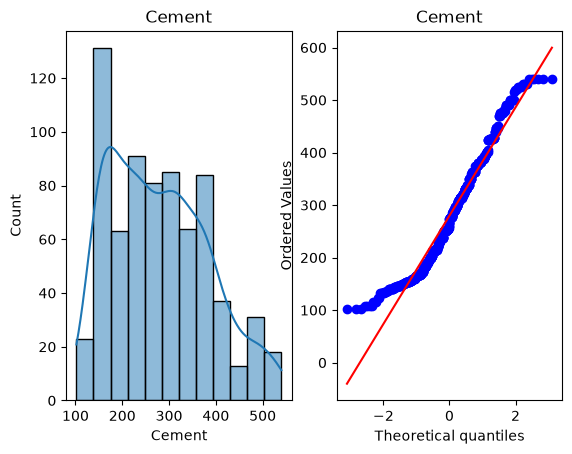

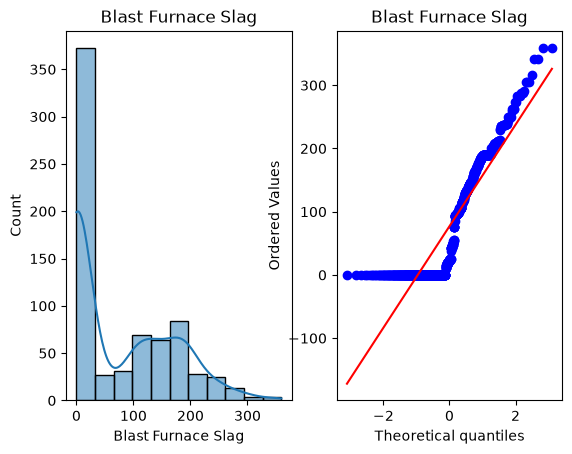

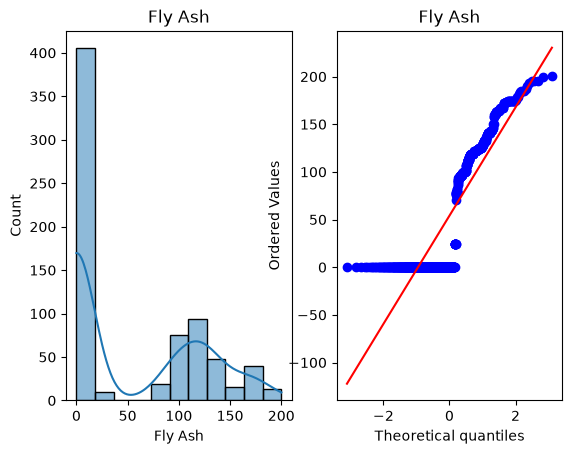

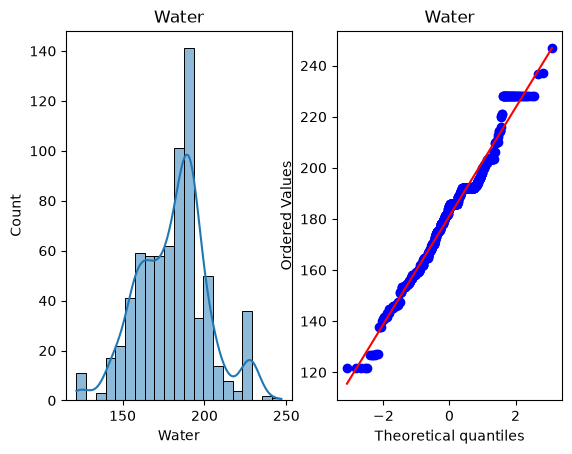

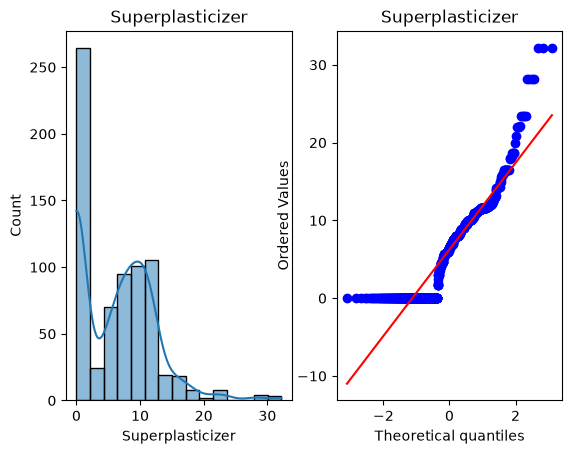

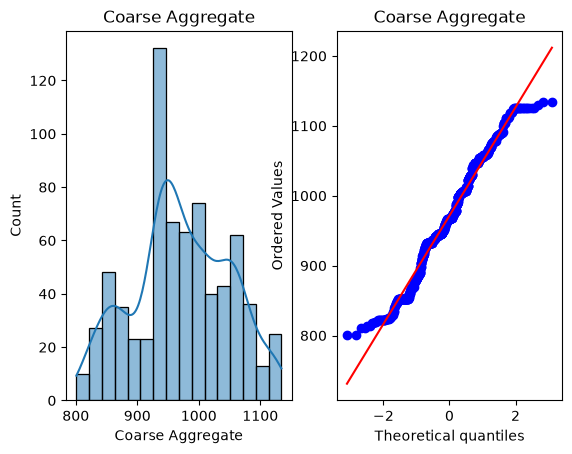

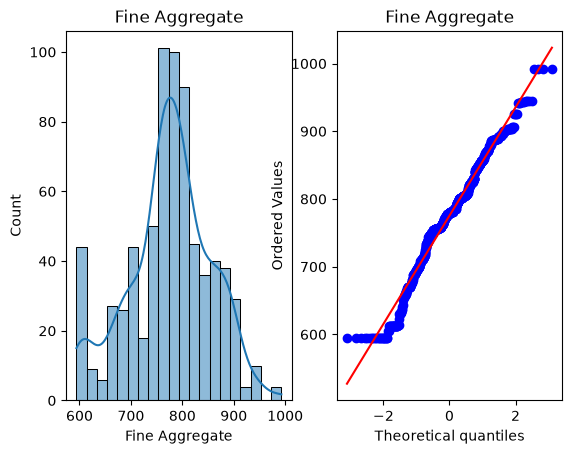

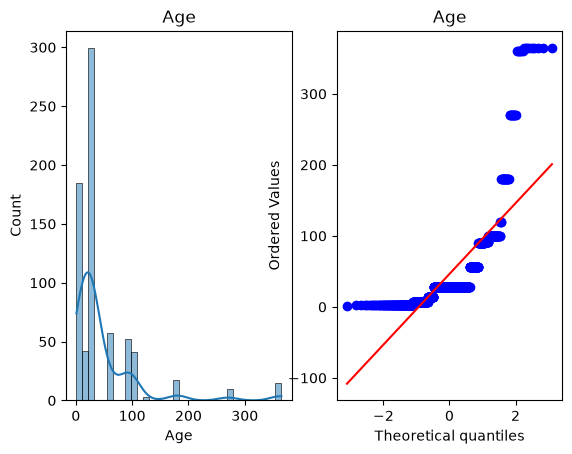

In [21]:
for i in X_train.columns:
    plt.subplot(1,2,1)
    sns.histplot(X_train[i], kde=True)
    plt.title(i)
    plt.subplot(1,2,2)
    stats.probplot(X_train[i],dist='norm',plot=plt)
    plt.title(i)

    plt.show()

In [22]:
X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
772,382.0,0.0,0.0,186.0,0.0,1047.0,739.0,7
997,310.0,142.8,0.0,167.9,10.0,914.3,804.0,28
724,310.0,0.0,0.0,192.0,0.0,1012.0,830.0,90
167,475.0,118.8,0.0,181.1,8.9,852.1,781.5,91
764,385.0,0.0,0.0,186.0,0.0,966.0,763.0,3
...,...,...,...,...,...,...,...,...
277,251.4,0.0,118.3,188.5,5.8,1028.4,757.7,56
763,385.0,0.0,0.0,186.0,0.0,966.0,763.0,1
835,144.0,0.0,175.0,158.0,18.0,943.0,844.0,28
559,239.6,359.4,0.0,185.7,0.0,941.6,664.3,28


In [24]:
pt=PowerTransformer(method='box-cox')

In [25]:
X_train_transformed=pt.fit_transform(X_train+0.000001)
X_test_transformed=pt.transform(X_test+0.000001)

In [26]:
X_test_transformed

array([[ 1.76733725, -1.0973204 , -0.883177  , ...,  1.98831909,
        -1.90984271, -1.68108465],
       [-1.86272641,  0.97261734, -0.883177  , ..., -0.17548936,
         0.27417037, -1.02012555],
       [ 0.85303485,  0.97647304, -0.883177  , ..., -0.34836066,
        -0.28309172,  1.12829162],
       ...,
       [-1.05819028,  0.90811617, -0.883177  , ..., -0.32149292,
         1.02287535, -1.02012555],
       [-0.35327049, -1.0973204 ,  1.13283311, ...,  0.74198869,
        -0.24859606, -0.46188091],
       [ 0.12823984, -1.0973204 ,  1.11862875, ...,  0.02599714,
         1.27981506,  0.11263863]], shape=(309, 8))

In [27]:
pt.lambdas_

array([ 0.18382756,  0.02847833, -0.04039694,  0.92527915,  0.10687527,
        1.14474701,  1.77161918,  0.04145838])

In [28]:
pd.DataFrame({'cols':X_train.columns,'box-cox-lambdas':pt.lambdas_})

,cols,box-cox-lambdas
0,Cement,0.183828
1,Blast Furnace Slag,0.028478
2,Fly Ash,-0.040397
3,Water,0.925279
4,Superplasticizer,0.106875
5,Coarse Aggregate,1.144747
6,Fine Aggregate,1.771619
7,Age,0.041458


In [29]:
X_t=pd.DataFrame(X_train_transformed,columns=X_train.columns)

In [30]:
X_t

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,0.997702,-1.097320,-0.883177,0.230484,-1.329181,0.970226,-0.487995,-1.020126
1,0.426274,0.937106,-0.883177,-0.620783,0.775266,-0.736327,0.324399,0.112639
2,0.426274,-1.097320,-0.883177,0.511278,-1.329181,0.516899,0.664063,1.118538
3,1.617732,0.911434,-0.883177,0.000668,0.743555,-1.524260,0.037215,1.128292
4,1.019535,-1.097320,-0.883177,0.230484,-1.329181,-0.075447,-0.194190,-1.681085
...,...,...,...,...,...,...,...,...
716,-0.125385,-1.097320,1.132833,0.347563,0.630370,0.729038,-0.259695,0.703908
717,1.019535,-1.097320,-0.883177,0.230484,-1.329181,-0.075447,-0.194190,-2.504236
718,-1.493183,-1.097320,1.161108,-1.089260,0.941374,-0.370104,0.850405,0.112639
719,-0.248990,1.067931,-0.883177,0.216427,-1.329181,-0.388007,-1.355672,0.112639


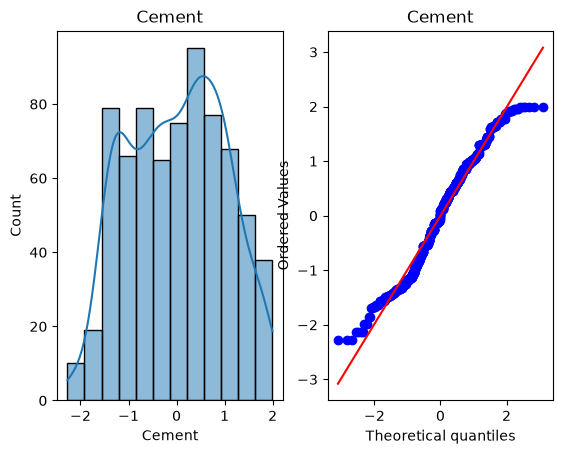

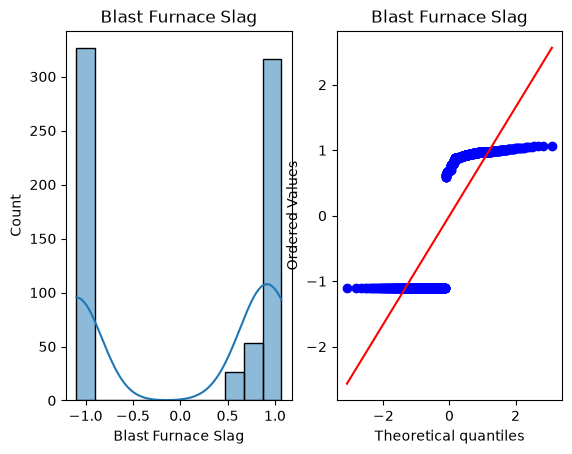

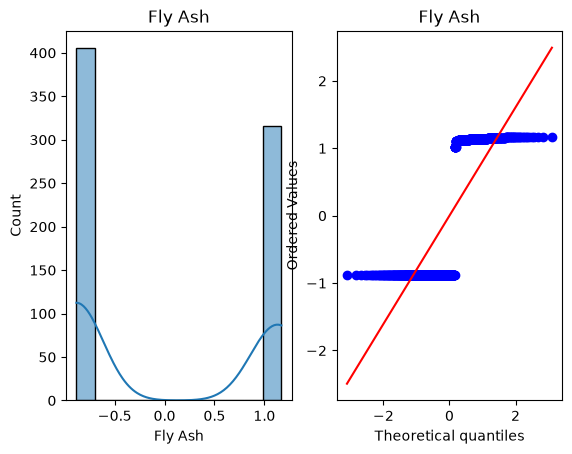

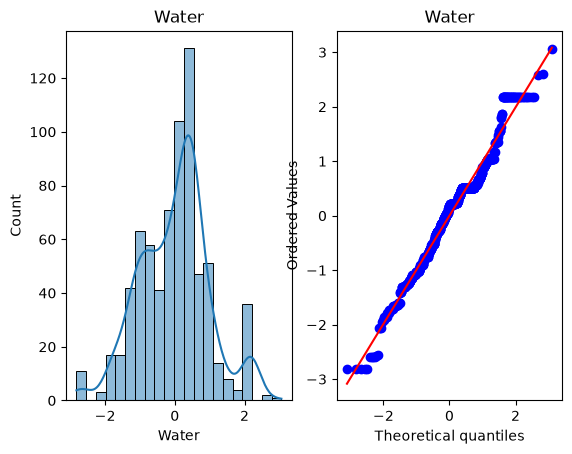

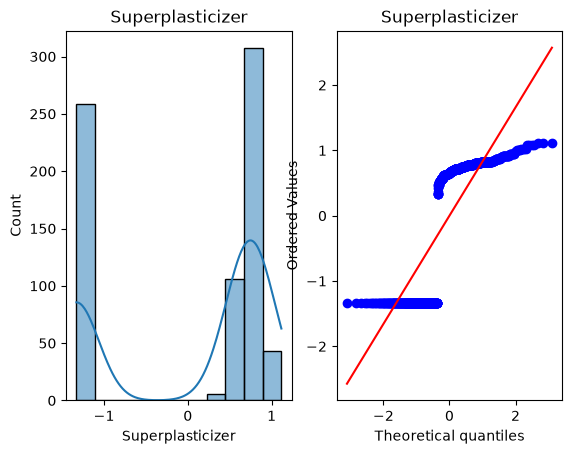

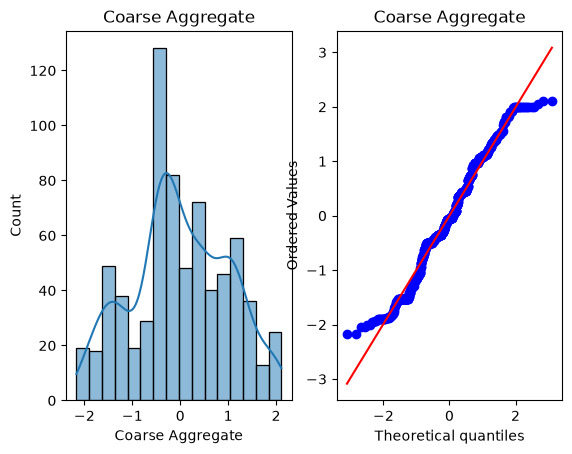

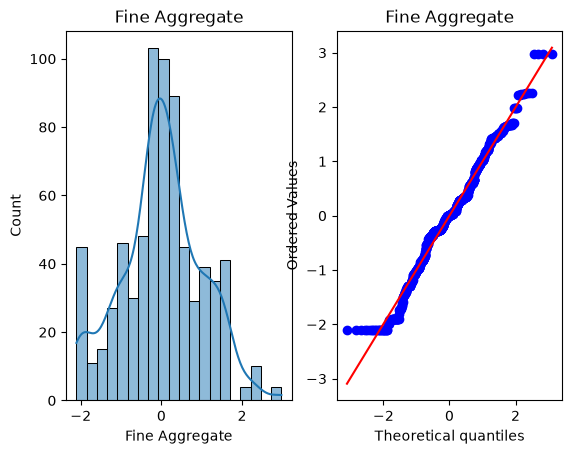

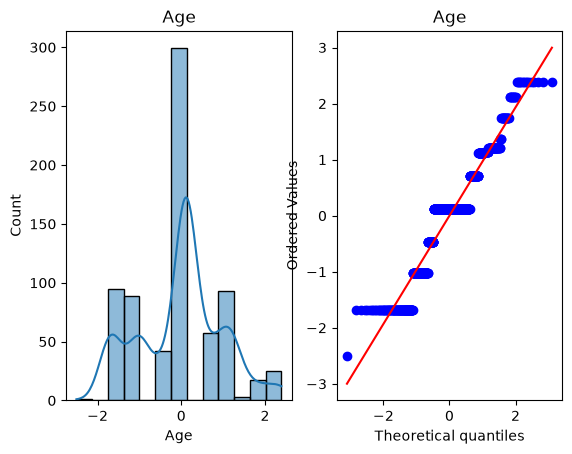

In [33]:
for i in X_t.columns:
    plt.subplot(1,2,1)
    sns.histplot(X_t[i],kde=True)
    plt.title(i)

    plt.subplot(1,2,2)
    stats.probplot(X_t[i],dist='norm',plot=plt)
    plt.title(i)
    plt.show()

In [34]:
pt1=PowerTransformer()

In [35]:
X_trained=pt1.fit_transform(X_train)
X_tested=pt1.transform(X_test)



In [37]:
X_trained

array([[ 0.99777827, -1.06739772, -0.88112668, ...,  0.97022589,
        -0.48799435, -1.04216741],
       [ 0.4262425 ,  0.97767753, -0.88112668, ..., -0.73632859,
         0.32439585,  0.11228239],
       [ 0.4262425 , -1.06739772, -0.88112668, ...,  0.51689624,
         0.66405913,  1.13057459],
       ...,
       [-1.49302839, -1.06739772,  1.23897288, ..., -0.37010823,
         0.85040144,  0.11228239],
       [-0.24913967,  1.38804993, -0.88112668, ..., -0.38801052,
        -1.35566664,  0.11228239],
       [-0.80467968,  1.28847022, -0.88112668, ..., -0.53874762,
        -0.76155275,  1.13057459]], shape=(721, 8))

In [40]:
X_y=pd.DataFrame(X_trained,columns=X_train.columns)

In [41]:
X_y

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,0.997778,-1.067398,-0.881127,0.230492,-1.242897,0.970226,-0.487994,-1.042167
1,0.426243,0.977678,-0.881127,-0.620780,0.785715,-0.736329,0.324396,0.112282
2,0.426243,-1.067398,-0.881127,0.511284,-1.242897,0.516896,0.664059,1.130575
3,1.617860,0.897371,-0.881127,0.000675,0.664270,-1.524254,0.037212,1.140276
4,1.019614,-1.067398,-0.881127,0.230492,-1.242897,-0.075451,-0.194191,-1.666898
...,...,...,...,...,...,...,...,...
716,-0.125519,-1.067398,1.134830,0.347570,0.260009,0.729035,-0.259696,0.714784
717,1.019614,-1.067398,-0.881127,0.230492,-1.242897,-0.075451,-0.194191,-2.294008
718,-1.493028,-1.067398,1.238973,-1.089263,1.478138,-0.370108,0.850401,0.112282
719,-0.249140,1.388050,-0.881127,0.216434,-1.242897,-0.388011,-1.355667,0.112282


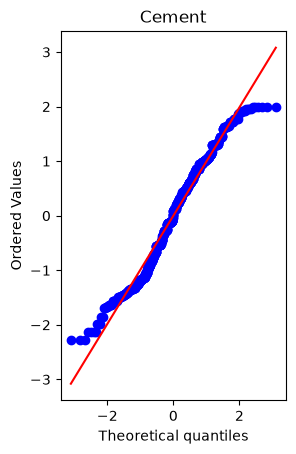

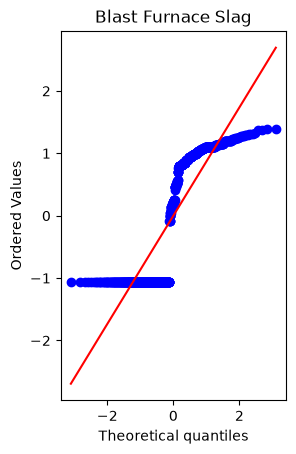

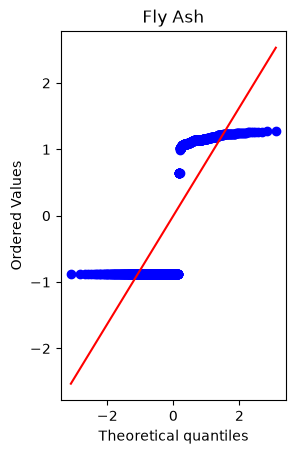

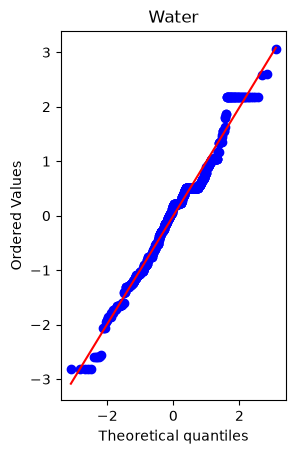

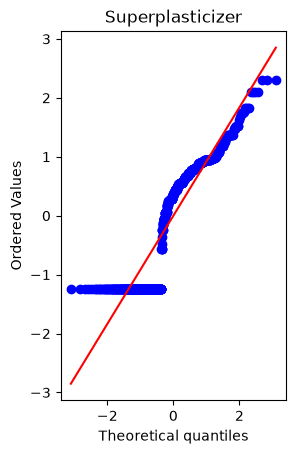

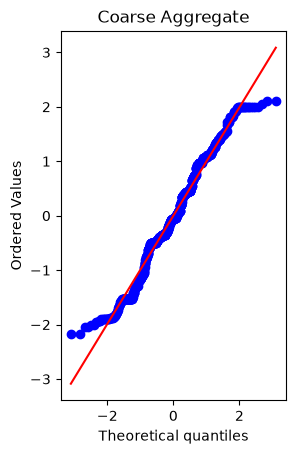

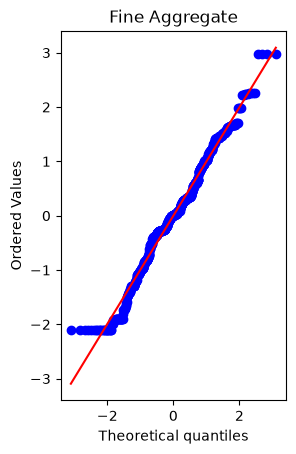

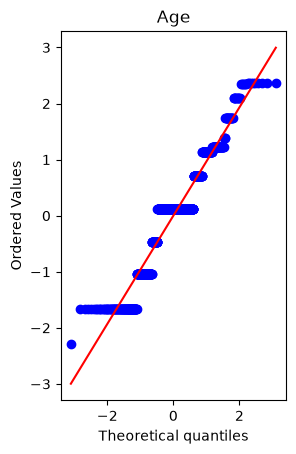

In [45]:
for i in X_y.columns:
    plt.subplot(1,2,1)
    stats.probplot(X_y[i],dist='norm',plot=plt)
    plt.title(i)
    plt.show()